<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Final-Project-/blob/main/3916_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict the median house value of a California census block group from its housing stock, demographic, and geographic characteristics?

**This is a prediction (umbrella) problem because:** We are asking whether a statistical model can forecast median home values given a set of observed covariates. We are not asking whether any individual feature (e.g. average rooms per household) causes higher home values, doing so would require a causal identification strategy that accounts for confounders like school quality, crime, and zoning. The goal is accurate forecasts, not counterfactual effects.
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:**  A local California real estate investor scanning listings needs a quick, data-driven benchmark for what a neighborhood's median home value should be given its demographic and housing fundamentals. With a calibrated predicted value plus an uncertainty band, the investor can flag blocks where individual listings are priced meaningfully below the model's prediction, candidates for closer diligence and potential acquisition, and conversely avoid overpaying in blocks where listing prices are at or above what the fundamentals justify. The investor does not need causal estimates (they are not trying to "change" a neighborhood's median income or housing age); they need an accurate benchmark and credible uncertainty so they know when a pricing gap is large enough to act on versus within the noise.
(Who is the stakeholder? What action would they take differently with your prediction?)

**Dataset:** California Housing (scikit-learn's fetch_california_housing)
- **Source:** Pace & Barry (1997), derived from the 1990 U.S. Census (URL:https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
- **N =** 20,640 census block groups
- **Features =** 8 numeric predictors: `MedInc` (median income, tens of \$1000s), `HouseAge`(median age of homes), `AveRooms`(average rooms per household), `AveBedrms`(average bedrooms per household), `Population`, `AveOccup`(average household size), `Latitude`, `Longitude`
- **Target variable =**  `MedHouseVal` — median house value for the block, in units of \$100,000
- **Access date:** April 19, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

# df.info()
# df.describe()

### 2.3 Missing Data Assessment

Missing data (%) by column:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64

Total missing cells: 0


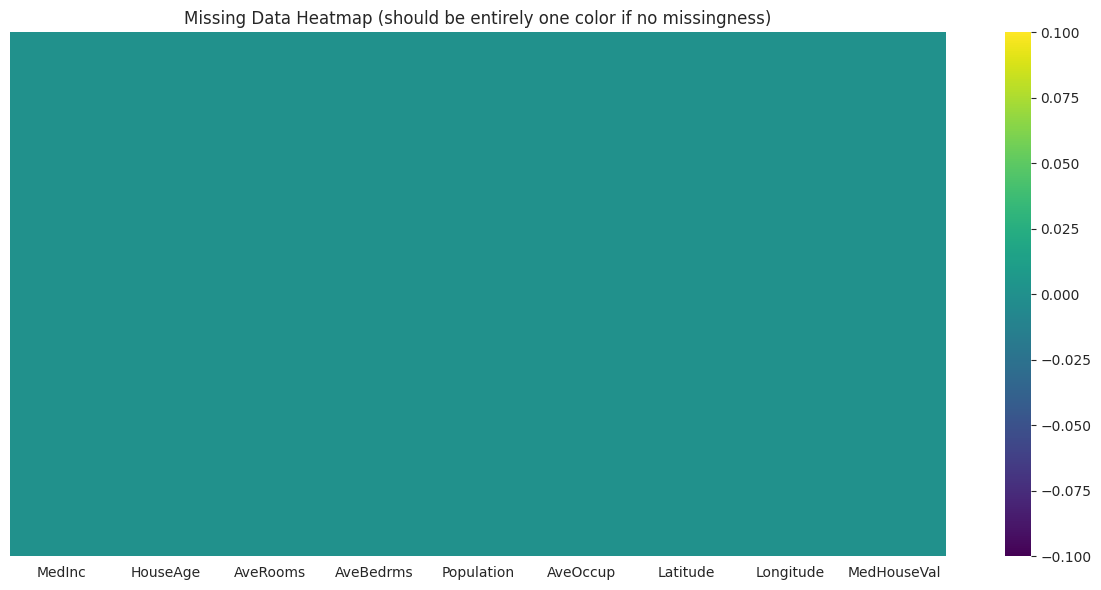

In [4]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap (should be entirely one color if no missingness)')
plt.tight_layout()
plt.show()

**Missing data strategy:** The California Housing dataset as distributed by scikit-learn has **zero missing values** across all 20,640 rows × 9 columns. At the row level, there is no missingness to classify.

However, the underlying 1990 Census itself is known to undercount certain populations (undocumented residents, transient households, the unhoused) in ways that correlate with the variables we care about. That is better understood as **measurement error / MNAR at the source**, not row-wise missingness we can impute away. I will flag this in the final report's Limitations section rather than attempt a correction here.

**For modeling:** No imputation needed. For robustness in the deployed Streamlit app I will still wrap the model in a `sklearn.Pipeline` that includes a `SimpleImputer(strategy='median')` step, so user-supplied inputs with missing fields don't crash the app.

### 2.4 Distribution Plots

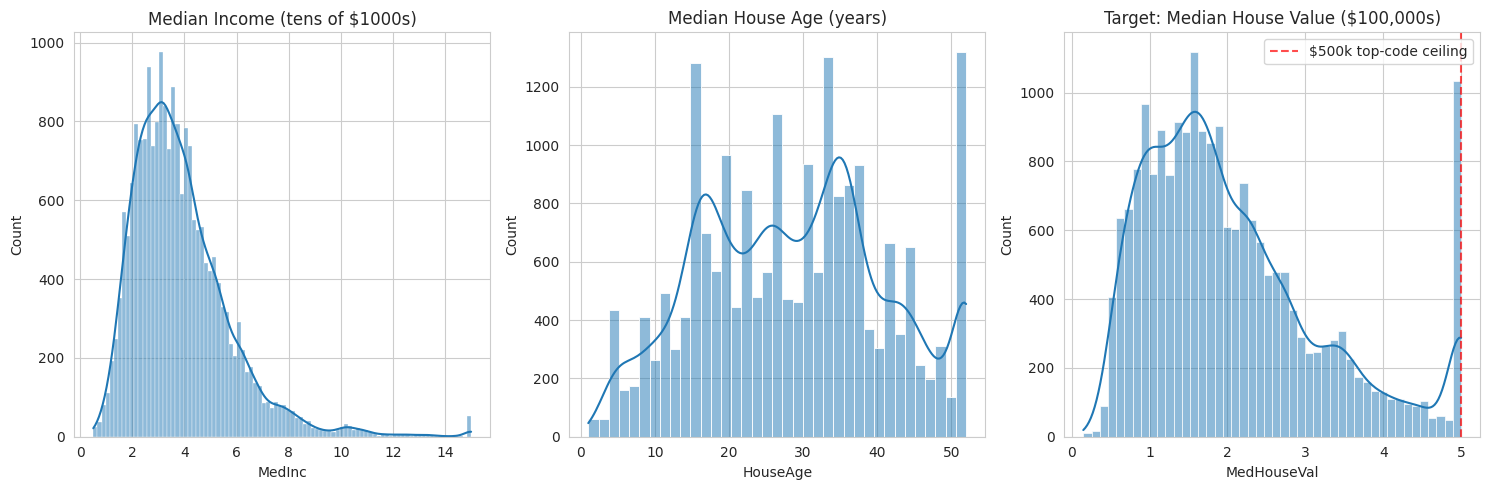

In [5]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['MedInc'], kde=True, ax=axes[0])
axes[0].set_title('Median Income (tens of $1000s)')
axes[0].set_xlabel('MedInc')

sns.histplot(df['HouseAge'], kde=True, ax=axes[1])
axes[1].set_title('Median House Age (years)')
axes[1].set_xlabel('HouseAge')

sns.histplot(df['MedHouseVal'], kde=True, ax=axes[2])
axes[2].axvline(5.0, color='red', linestyle='--', alpha=0.7,
                label='$500k top-code ceiling')
axes[2].set_title('Target: Median House Value ($100,000s)')
axes[2].set_xlabel('MedHouseVal')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [6]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Check outliers across all numeric columns
print(f'{"Column":<14}{"Lower fence":>12}{"Upper fence":>14}{"# outliers":>13}{"% outliers":>13}')
print('-' * 66)
for col in df.columns:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = 100 * len(outliers) / len(df)
    print(f'{col:<14}{lower:>12.2f}{upper:>14.2f}{len(outliers):>13d}{pct:>12.1f}%')

Column         Lower fence   Upper fence   # outliers   % outliers
------------------------------------------------------------------
MedInc               -0.71          8.01          681         3.3%
HouseAge            -10.50         65.50            0         0.0%
AveRooms              2.02          8.47          511         2.5%
AveBedrms             0.87          1.24         1424         6.9%
Population         -620.00       3132.00         1196         5.8%
AveOccup              1.15          4.56          711         3.4%
Latitude             28.26         43.38            0         0.0%
Longitude          -127.48       -112.33            0         0.0%
MedHouseVal          -0.98          4.82         1071         5.2%


**Outlier strategy:** The Tukey-fence scan flags large tails in `AveRooms`, `AveBedrms`, `Population`, and `AveOccup`, these almost certainly correspond to real but unusual census blocks (dormitories, group housing, industrial areas with tiny residential populations). Dropping them would throw away legitimate data the model needs to learn from.

**Plan:**
- **Keep all rows for the checkpoint.** The baseline linear model is sensitive to them, but a tree-based model (Random Forest / Gradient Boosting, added for the final) will naturally handle them.
- **For the final:** test a winsorized version of the four skewed features (cap at the 99th percentile) as one variant in the model comparison, and report whether it meaningfully changes held-out performance.
- **Target-variable ceiling:** the $500k top-code on `MedHouseVal` is a different kind of "outlier", it's not noise, it's censored observation. Addressed separately in the data-quality summary and the report's Limitations section.

### 2.6 Correlations

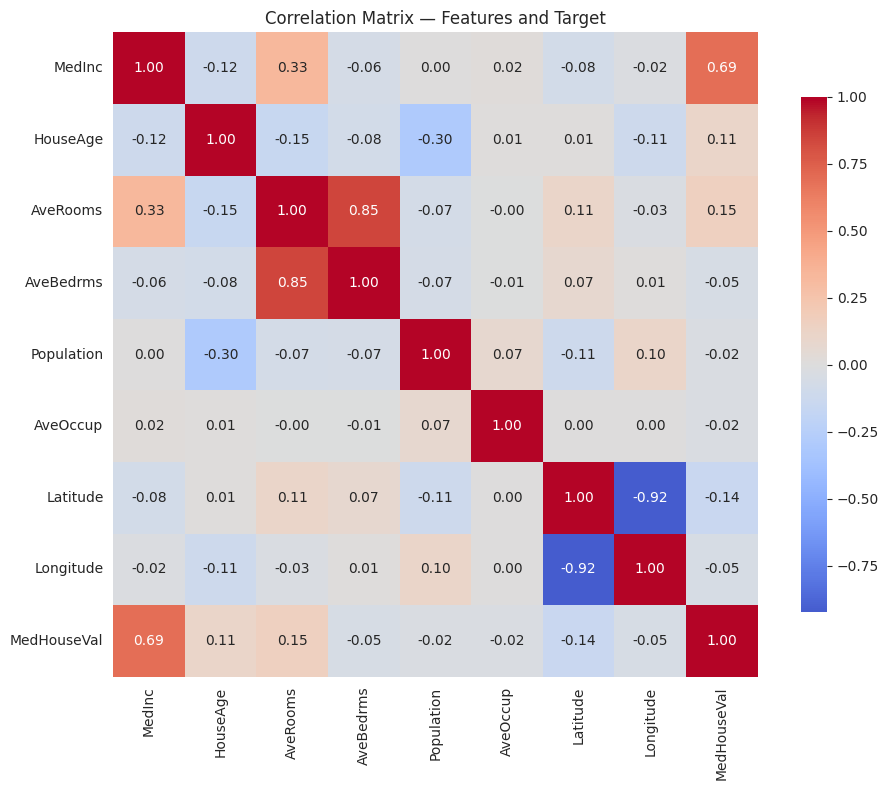

In [7]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Features and Target')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* `MedHouseVal` is right-skewed with a pronounced spike at 5.0, the $500,000 top-code ceiling imposed by the 1990 Census (~5% of rows). Ordinary linear regression will systematically under-predict genuinely high-value blocks because the training signal for those neighborhoods is censored. For the final I will (a) try a log-transform of the target, (b) flag ceiling-bound predictions in the Streamlit app with a wider uncertainty interval, and (c) explicitly call out this limitation in the report.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?

   *Your answer:* `MedInc` is the dominant linear predictor (r ≈ 0.69 with `MedHouseVal`). `Latitude` and `Longitude` each have moderate correlations with the target, consistent with the coastal-vs-inland price gradient in California. The main multicollinearity concern is between `AveRooms` and `AveBedrms` (r ≈ 0.85), this inflates standard errors on the linear-model coefficients and motivates Ridge/Lasso regularization in the final model comparison.

3. **What is the biggest data quality issue you found, and how will you handle it?**

   *Your answer:* The target's $500k top-code is the biggest issue. It is structural measurement error, not noise, no amount of modeling on the cleaned data recovers the true distribution above the ceiling. My strategy for the final report: fit the model on the data as-is, but (i) report two RMSE figures, full sample and ceiling-excluded, so the ceiling's effect is visible, and (ii) surface the top-code explicitly in the Streamlit dashboard as a warning label whenever the predicted value is near 5.0.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 20,640** observations and **M = 8** features (plus 1 target).

**Missing data:** 0% of cells are missing. Row-level missingness is not applicable. The underlying 1990 Census undercounts certain populations in ways best described as **MNAR at the source** (measurement error in how the data was collected, not missingness in the distributed file). I will handle it by calling this out in the Limitations section; no imputation is needed on the file itself.

**Outliers:** Tukey-fence scans flag several hundred rows in `AveRooms`, `AveBedrms`, `Population`, and `AveOccup`, these reflect real unusual block groups (dorms, group housing) rather than recording errors. I will keep them for the checkpoint and test a winsorized variant (cap at 99th percentile) during the final model comparison.

**Target variable:** `MedHouseVal` is right-skewed with a hard ceiling at 5.0 (= $500k top-code). Mean ≈ 2.07, median ≈ 1.80, max ≈ 5.00.

**Key finding from EDA:** Median income is by far the strongest linear correlate of home values (r ≈ 0.69), but the target's top-code ceiling and the non-linear spatial structure (captured by Latitude/Longitude) suggest a flexible, tree-based model should outperform plain linear regression on held-out data.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [8]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# Features and target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# This is regression — no stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]} samples')

Train: 16512 samples, 8 features
Test:  4128 samples


### 3.2 Model 1: Baseline

In [9]:
# ============================================================
# 3.2 Model 1 — Baseline: Linear Regression
# ============================================================
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

# Regression metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_1))
mae  = mean_absolute_error(y_test, y_pred_1)
r2   = r2_score(y_test, y_pred_1)

print('Model 1: Linear Regression (baseline)')
print(f'  RMSE : {rmse:.4f}  (i.e. ~${rmse*100_000:,.0f})')
print(f'  MAE  : {mae:.4f}')
print(f'  R^2  : {r2:.4f}')

# Coefficient inspection — PREDICTIVE, NOT CAUSAL
coef_df = (
    pd.DataFrame({'feature': X.columns, 'coefficient': model_1.coef_})
      .sort_values('coefficient', key=abs, ascending=False)
      .reset_index(drop=True)
)
print('\nCoefficients (predictive association, NOT causal effect):')
print(coef_df.to_string(index=False))

Model 1: Linear Regression (baseline)
  RMSE : 0.7456  (i.e. ~$74,558)
  MAE  : 0.5332
  R^2  : 0.5758

Coefficients (predictive association, NOT causal effect):
   feature  coefficient
 AveBedrms     0.783145
    MedInc     0.448675
 Longitude    -0.433708
  Latitude    -0.419792
  AveRooms    -0.123323
  HouseAge     0.009724
  AveOccup    -0.003526
Population    -0.000002


### 3.3 Model 2: Your Choice

In [ ]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

# from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
#
# model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
# model_2.fit(X_train, y_train)
#
# y_pred_2 = model_2.predict(X_test)
#
# print('Model 2: Random Forest')
# print(classification_report(y_test, y_pred_2))

### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
# scoring = 'accuracy'
#
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
# comparison = pd.DataFrame({
#     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
#     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
#     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
# })
# comparison

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___